In [119]:
import torch
from generate_utils import load_GraphModel, load_BiLSTMModel, load_TokenBiLSTMModel
from GridMLM_tokenizers import CSGridMLMTokenizer
from graph_utils import get_graph_embeddings_from_string_with_model, get_bilstm_embeddings_from_string_with_model, get_token_bilstm_embeddings_from_string_with_model, make_graph_ready_for_token_ids
import numpy as np
import matplotlib.pyplot as plt
import os

In [120]:
tokenizer = CSGridMLMTokenizer(
    fixed_length=80,
    quantization='4th',
    intertwine_bar_info=True,
    trim_start=False,
    use_pc_roll=True,
    use_full_range_melody=False
)

In [121]:
device_name = 'cuda:2'
device = torch.device(device_name)

In [122]:
graph_model_path = f'saved_models/LoRA/graph/graph_model_contra_jnhw.pt'
graph_model = load_GraphModel(graph_model_path, device)
graph_model.eval()

bilstm_model_path = 'saved_models/LoRA/bilstm/bilstm_model_contra_jnhw.pt'
bilstm_model = load_BiLSTMModel(bilstm_model_path, device)
bilstm_model.eval()

token_bilstm_model_path = 'saved_models/LoRA/token_bilstm/bilstm_model_contra_jnhw.pt'
token_bilstm_model = load_TokenBiLSTMModel(token_bilstm_model_path, tokenizer, device)
token_bilstm_model.eval()

TokenHarmonyBiLSTM(
  (embedding): Embedding(355, 256, padding_idx=0)
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (attn): Linear(in_features=512, out_features=1, bias=True)
  (output_proj): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=512, bias=True)
  )
)

In [123]:
# in_seq = 'b_C#:hdim7_@4b_D:hdim7_@4'
# in_seq = 'b_A#:7_@2;A:min6_@2'
# in_seq = 'b_E:7_@2;A:min_@2'
in_seq = 'b_E:7_@4b_A:min_@4'
# in_seq = 'b_A:min_@4b_E:7_@4'
# in_seq = 'b_D:min7_@4b_B:hdim7_@4'
# in_seq = 'b_B:hdim7_@4b_D:min7_@4'

In [124]:
y_graph = get_graph_embeddings_from_string_with_model(in_seq, graph_model)
y_bilstm = get_bilstm_embeddings_from_string_with_model(in_seq, bilstm_model)
y_token_bilstm = get_token_bilstm_embeddings_from_string_with_model(in_seq, token_bilstm_model)

In [125]:
# tokenize file
files_root = 'midi_tests'
file_names = os.listdir(files_root)
file_name = file_names[3]

file_path = os.path.join(files_root, file_name)
print(file_path)

tokenized = tokenizer.encode(file_path)

midi_tests/gen_Autumn_Leaves_no.mid


In [126]:
harmony_ids = tokenized['harmony_ids']
print(tokenized['harmony_ids'])
m = make_graph_ready_for_token_ids(harmony_ids, tokenizer)

[6, 269, 269, 269, 269, 6, 73, 73, 73, 73, 6, 216, 216, 216, 216, 6, 14, 14, 14, 14, 6, 73, 73, 73, 73, 6, 339, 339, 339, 339, 6, 339, 339, 129, 129, 6, 269, 269, 269, 269, 6, 269, 269, 269, 269, 6, 339, 339, 148, 148, 6, 276, 276, 276, 276, 6, 269, 269, 269, 269, 6, 339, 339, 339, 339, 6, 339, 339, 339, 148, 6, 269, 269, 269, 269, 6, 269, 269, 339, 339]


In [127]:
m.make_token_seq_of_segment(0,2)
print(m.segment_tokens)

tensor([269,  73])


In [128]:
m.make_token_seq_of_segment(1,3)
print(m.segment_tokens)

tensor([ 73, 216])


In [129]:
cos = torch.nn.CosineSimilarity()
# prepare a 16-bar zero background for similarity per bar
per_bar_similarity = {
    'graph': np.zeros(15),
    'bilstm': np.zeros(15),
    'token': np.zeros(15)
}

In [130]:
num_seg_lens = 0
seg_len, seg_step = 2, 1
bar_start = 0
bar_end = bar_start + seg_len
while bar_end <= m.num_bars:
    m.make_graph_of_segment(bar_start, bar_end)
    m.make_bilstm_seq_of_segment(bar_start, bar_end)
    m.make_token_seq_of_segment(bar_start, bar_end)
    # graph
    seg_y_graph = graph_model(m.segment_graph)
    graph_sim = cos(y_graph, seg_y_graph).item()
    per_bar_similarity['graph'][bar_start] += graph_sim
    # print(per_bar_similarity['graph'][1])
    # bilstm
    seg_y_bilstm = bilstm_model(m.segment_bilstm.unsqueeze(0).to(device), torch.tensor([m.segment_bilstm.shape[0]]).to(device))
    bilstm_sim = cos(y_bilstm, seg_y_bilstm).item()
    per_bar_similarity['bilstm'][bar_start] += bilstm_sim
    # token
    seg_y_token = token_bilstm_model(m.segment_tokens.unsqueeze(0).to(device), torch.tensor([m.segment_tokens.shape[0]]).to(device))
    tokens_sim = cos(y_token_bilstm, seg_y_token).item()
    per_bar_similarity['token'][bar_start] += tokens_sim
    print(f'bar_start: {bar_start:02} - bar_end: {bar_end:02} | ')
    chord_symbols = [tokenizer.ids_to_tokens[chord_id.item()] for chord_id in m.segment_tokens]
    print(chord_symbols)
    print(f'g: {graph_sim:.4f} | b: {bilstm_sim:.4f} | t: {tokens_sim:.4f}')
    print('============ =============== ===============')
    bar_start += seg_step
    bar_end = bar_start + seg_len

bar_start: 00 - bar_end: 02 | 
['A:min', 'D:min7']
g: -0.3013 | b: 0.4969 | t: 0.4634
============ =============== ===============
bar_start: 01 - bar_end: 03 | 
['D:min7', 'G:7']
g: -0.3620 | b: 0.4427 | t: 0.4212
============ =============== ===============
bar_start: 02 - bar_end: 04 | 
['G:7', 'C:maj7']
g: 0.6745 | b: 0.4955 | t: 0.5926
============ =============== ===============
bar_start: 03 - bar_end: 05 | 
['C:maj7', 'D:min7']
g: 0.2558 | b: 0.3664 | t: 0.4079
============ =============== ===============
bar_start: 04 - bar_end: 06 | 
['D:min7', 'B:hdim7']
g: -0.0729 | b: 0.5026 | t: 0.4088
============ =============== ===============
bar_start: 05 - bar_end: 07 | 
['B:hdim7', 'B:hdim7', 'E:7']
g: -0.0921 | b: 0.5683 | t: 0.5667
============ =============== ===============
bar_start: 06 - bar_end: 08 | 
['B:hdim7', 'E:7', 'A:min']
g: 0.2450 | b: 0.7911 | t: 0.8154
============ =============== ===============
bar_start: 07 - bar_end: 09 | 
['A:min', 'A:min']
g: 0.1447 | b: 0.71

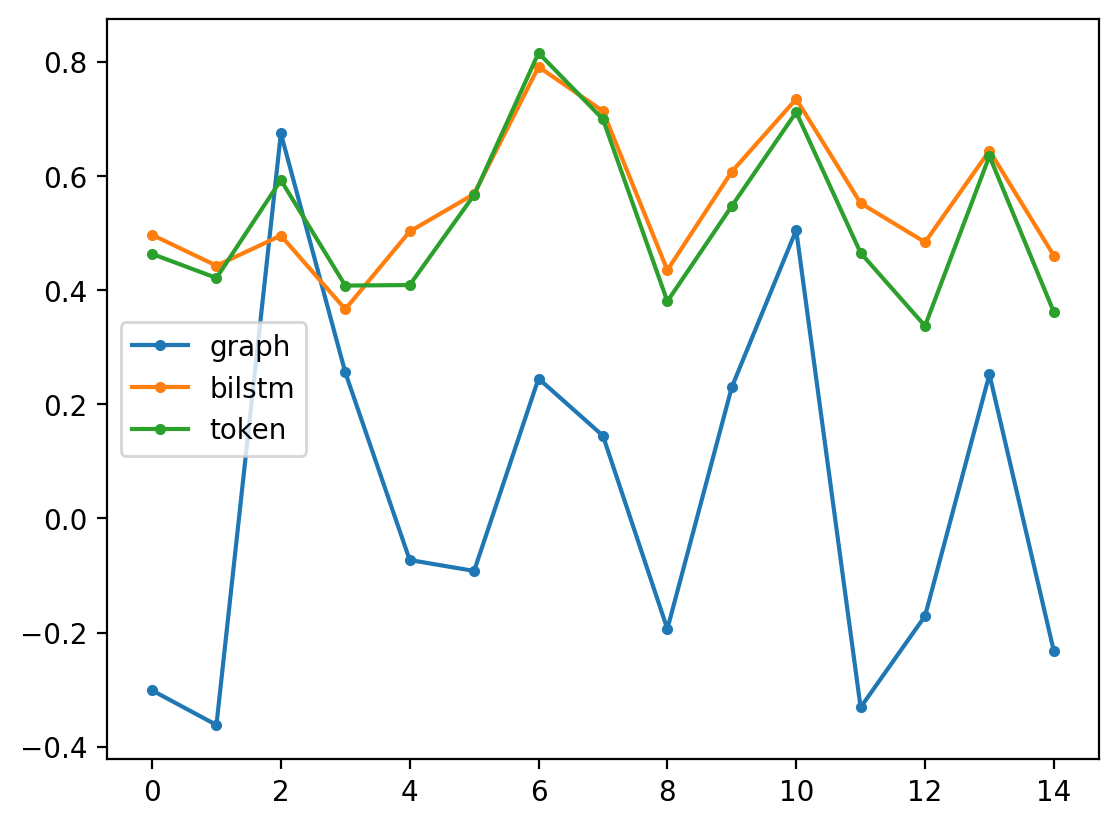

In [131]:
figs_folder = 'figs/similarity_tests/'
os.makedirs(figs_folder, exist_ok=True)

plt.plot(per_bar_similarity['graph'], '.-')
plt.plot(per_bar_similarity['bilstm'], '.-')
plt.plot(per_bar_similarity['token'], '.-')
plt.legend(['graph', 'bilstm', 'token'])
plt.savefig(f'{figs_folder}/{file_name}_{in_seq}.png', dpi=300)